# Is the screen any good?

Before calling hits, check that the screen measured something: that perturbations can be told from the
controls, which features are reproducible, how much plate structure is left, and whether more replicates
would help.

In [1]:
import matplotlib.pyplot as plt

import mantispy as mt

## A real screen

BBBC021 {cite:p}`Ljosa_2013`: MCF-7 cells, 38 compounds at one to seven concentrations with 12 mechanisms of
action, two or three replicate wells per treatment. This downloads about 10 MB.

In [2]:
adata = mt.ds.bbbc021()
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")
mt.pp.feature_select(adata, na_cutoff=0.0)
adata = mt.pp.subset_features(adata)

treated = adata[~adata.obs["Metadata_Control"].to_numpy()].copy()
treated.shape

<path>:2: UserWarning: 2 of 467 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")


(302, 343)

## Can a treatment be told from the controls?

Mean average precision (mAP) asks a retrieval question: when profiles are ranked by
similarity to one profile, do its replicates rank above the profiles that should not match? It
is rank-based, so it needs no correlation threshold, and its permutation null gives every
group a p-value.

`tl.map` wraps [copairs](https://github.com/cytomining/copairs) {cite:p}`Kalinin_2025`, the Broad's implementation,
so the numbers are comparable with published ones.

Compare mAP with its null, not with an intuition about scores between zero and one. Unlike
accuracy, it has no fixed chance level: a random ranking's score depends on how many positives
each query has, so 0.14 can be a strong result on one screen and noise on another. `null_size`
and the `corrected_p_value` column account for this.

In [3]:
mt.tl.map(adata, mode="activity")
activity = adata.uns["mantispy"]["map"]
print(f"{int(activity['below_corrected_p'].sum())} of {len(activity)} treatments told apart from DMSO at q < 0.05")
activity.sort_values("mean_average_precision")[["Metadata_Perturbation", "mean_average_precision", "corrected_p_value"]]

80 of 103 treatments told apart from DMSO at q < 0.05


,Metadata_Perturbation,mean_average_precision,corrected_p_value
48,colchicine@0.03,0.314286,0.606939
72,floxuridine@30.0,0.558730,0.281404
73,lactacystin@10.0,0.611111,0.247481
88,proteasome inhibitor I@0.1,0.633333,0.210408
42,bryostatin@0.3,0.666667,0.148555
...,...,...,...
27,AZ258@0.3,1.000000,0.000156
26,AZ258@0.1,1.000000,0.000156
25,AZ138@3.0,1.000000,0.000156
40,anisomycin@0.3,1.000000,0.000156


80 of the 103 treatments are told apart from DMSO at q < 0.05, and several retrieve their replicates perfectly. At
the bottom is colchicine, tested at a single dose of 0.03 uM. There is no DMSO row: in `mode="activity"` the negative
controls are the reference set every treatment is scored against, so they are not scored themselves.

`mode="cross_plate"` asks a stricter question: replicates must retrieve each other across plates, which separates
reproducible biology from a plate that happened to look uniform. `percent_replicating` and `grit` are older
readouts, kept because many published numbers use them.

## Which features can I trust?

A feature with high variance can still be useless. If that variance lies within replicates of
the same treatment rather than between treatments, it is noise. A variance filter cannot tell
the difference because it ignores the replicate structure.

`pp.feature_reproducibility` computes the intraclass correlation (ICC), the share of a
feature's variance that lies between replicate groups.

In [4]:
mt.pp.feature_reproducibility(treated, groupby="Metadata_Perturbation")
icc = treated.var["icc"]
{
    "median": round(float(icc.median()), 3),
    "lower quartile": round(float(icc.quantile(0.25)), 3),
    "upper quartile": round(float(icc.quantile(0.75)), 3),
    "features above 0.2": int((icc > 0.2).sum()),
    "of": int(treated.n_vars),
}

{'median': 0.387,
 'lower quartile': 0.207,
 'upper quartile': 0.537,
 'features above 0.2': 262,
 'of': 343}

Does selecting on ICC help? The answer differs between two retrieval tasks.

Replicate retrieval, whether a treatment's replicates find each other, is what mAP measures.

In [5]:
def replicate_map(profiles):
    """Mean average precision of replicate retrieval."""
    scratch = profiles.copy()
    mt.tl.map(scratch, mode="replicability", null_size=500, seed=0)
    return float(scratch.uns["mantispy"]["map"]["mean_average_precision"].mean())


{
    "all features": round(replicate_map(treated), 3),
    "ICC > 0.2": round(replicate_map(treated[:, (icc > 0.2).to_numpy()].copy()), 3),
    "ICC > 0.4": round(replicate_map(treated[:, (icc > 0.4).to_numpy()].copy()), 3),
}

<path>:4: UserWarning: 3 profile(s) have replicates but no negative pair to rank them against, and are left out. They are in [{'Metadata_Plate': 'Week6_31641'}, {'Metadata_Plate': 'Week6_31661'}, {'Metadata_Plate': 'Week6_31681'}].
  mt.tl.map(scratch, mode="replicability", null_size=500, seed=0)
<path>:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over 102 groups calls none of them unless at least 5 reach that floor together. Raise null_size above 2040 for one group to be callable on its own.
  mt.tl.map(scratch, mode="replicability", null_size=500, seed=0)
<path>:4: UserWarning: 3 profile(s) have replicates but no negative pair to rank them against, and are left out. They are in [{'Metadata_Plate': 'Week6_31641'}, {'Metadata_Plate': 'Week6_31661'}, {'Metadata_Plate': 'Week6_31681'}].
  mt.tl.map(scratch, mode="replicability", null_size=500, seed=0)
<path>:4: UserWarning: with null_size=500 no p-value can fall below 1/501, so the correction over

{'all features': 0.317, 'ICC > 0.2': 0.343, 'ICC > 0.4': 0.369}

Replicate retrieval improves, from 0.317 with every feature to 0.369 above an ICC of 0.4.

Mechanism retrieval, whether a compound finds a different compound with the same mechanism,
is the task from [Mechanism of action](../compounds/mechanism_of_action.ipynb). Here the same filter does not help.

In [6]:
def not_same_compound(profiles):
    """Not-same-compound mechanism retrieval."""
    signatures = mt.tl.consensus(profiles.copy(), method="median", min_replicates=1)
    signatures = signatures[signatures.obs["Metadata_MOA"].notna().to_numpy()].copy()
    mt.tl.nn_moa_classify(signatures, scheme="nsc")
    return float(signatures.uns["mantispy"]["moa"]["accuracy"])


{
    "all features": round(not_same_compound(treated), 3),
    "ICC > 0.2": round(not_same_compound(treated[:, (icc > 0.2).to_numpy()].copy()), 3),
    "ICC > 0.4": round(not_same_compound(treated[:, (icc > 0.4).to_numpy()].copy()), 3),
}

{'all features': 0.777, 'ICC > 0.2': 0.767, 'ICC > 0.4': 0.757}

Reproducible and generalizable are different properties. ICC favors features whose
replicates agree, which is what replicate retrieval rewards. Transferring from one molecule to
another with the same mechanism needs something else, and filtering on reproducibility
slightly hurts it here.

Use ICC when the question is reproducibility. For other tasks, measure its effect first, and
choose the cutoff from the ICC distribution instead of using a default.

## How much of this is batch effect?

`pp.feature_batch_sensitivity` tests each feature for dependence on batch with a
Kruskal-Wallis test and corrects for multiple testing across features. Run it on wells that
received the same treatment on every plate, such as the controls: BBBC021's plates hold different compounds,
so a test on its treated wells would mix batch with treatment.

In [7]:
raw = mt.ds.bbbc021()[:, adata.var_names].copy()
controls = raw[raw.obs["Metadata_Control"].to_numpy()].copy()
mt.pp.feature_batch_sensitivity(controls, batch_key="Metadata_Plate")
{
    "plates": int(controls.obs["Metadata_Plate"].nunique()),
    "features plate-dependent among the DMSO wells, before normalization": int(controls.var["batch_sensitive"].sum()),
    "of": int(controls.n_vars),
}

{'plates': 55,
 'features plate-dependent among the DMSO wells, before normalization': 335,
 'of': 343}

Before normalization, 335 of the 343 features differ between the plates' DMSO wells. Normalizing each plate
against its own controls centres them, so after it the controls cannot differ; what it leaves is how features
respond within a plate, which only plates holding the same treatments can show.

Treat this as a warning against interpreting small effects across plates. Compare a corrected
run with an uncorrected one to see whether the count drops, and evaluate corrections with
`mt.metrics.evaluate_correction`.

## How many replicates do I need?

`tl.replicate_saturation` subsamples replicates and reports how much the signature still
changes at each depth. There are two metrics, and the number of replicates in the screen
decides which one applies:

- `"signature_stability"` correlates two disjoint subsets. It is unbiased and needs
  `2 * depth` replicates.
- `"convergence"` correlates a subset with the group's full signature. It is defined up to
  one less than the group size and is optimistic by construction.

BBBC021 has at most three replicates per treatment, so the unbiased measure gives a single point.

In [8]:
mt.tl.replicate_saturation(treated, metric="convergence", n_draws=10)
treated.uns["mantispy"]["replicate_saturation"].round(3)

,n_replicates,mean,std,n_draws
0,1,0.793,0.009,10
1,2,0.873,0.004,10


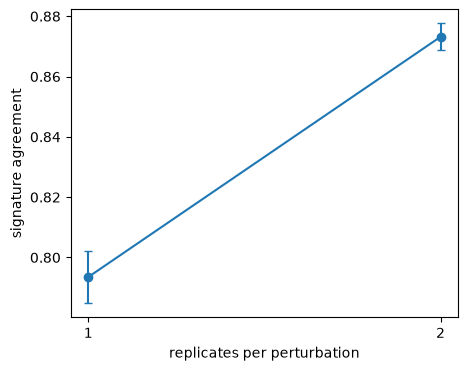

In [9]:
ax = mt.pl.replicate_saturation(treated)
plt.show()

From one replicate to two, signature agreement rises from 0.79 to 0.87 and is still rising at
the largest depth the data supports. For an experiment that has to distinguish mechanisms,
three replicates is on the low side, which is useful when planning the next screen.

## Summary

- mAP against the controls says whether a perturbation did anything; compare it with its null, not with an
  intuition about scores between zero and one.
- Reproducible and generalizable are different properties, and a filter that improves one can hurt the
  other. Measure the task you care about.
- Plates differ even where they received the same treatment. Test for it on the controls.
- A saturation curve that is still rising says the next experiment needs more replicates.